In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import csv
import os
import pickle

from functools import lru_cache

In [2]:
@lru_cache
def rfsoc_data(date, time, exp_name, year='2025'):
    with h5py.File(rfsoc_filename(date, time, exp_name, year=year), 'r') as file:
        return {k: file[k][()] for k in file.keys()}
    
@lru_cache
def rfsoc_file(filename):
    with h5py.File(filename, 'r') as file:
        return {k: file[k][()] for k in file.keys()}
    

def rfsoc_filename(date, time, exp_name, suffix='data', year='2025'):
    month, day = date[0:2], date[2:4]
    h, m, s = time[0:2], time[2:4], time[4:6] # hour, minute, second
    return fr'V:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\{exp_name}\{exp_name}_{year}_{month}_{day}\{exp_name}_{year}_{month}_{day}_{h}_{m}_{s}_{suffix}.h5'

# 1. Pulse Timiing Experiment

In [3]:
d = rfsoc_data("0814", "113846", "FF_drive_timing", year="2025")
print(d.keys())
pop, t_off = d['population'], d['expt_samples']
t_off_ns =  t_off *(4.64/16)
print(pop.shape)
plt.plot(t_off_ns, pop[0], '-o')

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'V:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_drive_timing\FF_drive_timing_2025_08_14\FF_drive_timing_2025_08_14_11_38_46_data.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:

pulse_timing_data_filename = 'supplement_data/pulse_timing_data.csv'

with open(pulse_timing_data_filename, 'w') as f:

    writer = csv.writer(f)
    writer.writerow(t_off_ns)
    writer.writerow(pop[0])
    

# 2. Pulse Compensation

In [6]:

class DictUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        # replace objects from ff_comp with a simple object
        class Dummy:
                pass
        if module == "ff_comp":
            return Dummy
        elif module == "coupler_ac_fitter":
            return Dummy
        return super().find_class(module, name)


[  4.62158256   6.94673136   9.27188016  11.59702896  13.92217776
  16.24732656  18.57247536  20.89762416  23.22277296  25.54792176
  27.87307056  30.19821936  32.52336816  34.84851696  37.17366576
  39.49881456  41.82396336  44.14911216  46.47426096  48.79940976
  51.12455856  53.44970736  55.77485616  58.10000496  60.42515376
  62.75030256  65.07545136  67.40060016  69.72574896  72.05089776
  74.37604656  76.70119536  79.02634416  81.35149296  83.67664176
  86.00179056  88.32693936  90.65208816  92.97723696  95.30238576
  97.62753456  99.95268336 102.27783216 104.60298096 106.92812976
 109.25327856 111.57842736 113.90357616 116.22872496 118.55387376
 120.87902256 123.20417136 125.52932016 127.85446896 130.17961776
 132.50476656 134.82991536 137.15506416 139.48021296 141.80536176
 144.13051056 146.45565936 148.78080816 151.10595696 153.43110576
 155.75625456 158.08140336 160.40655216 162.73170096 165.05684976
 167.38199856 169.70714736 172.03229616 174.35744496 176.68259376
 179.00774

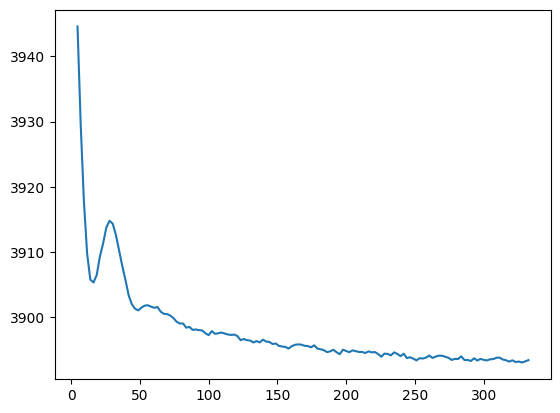

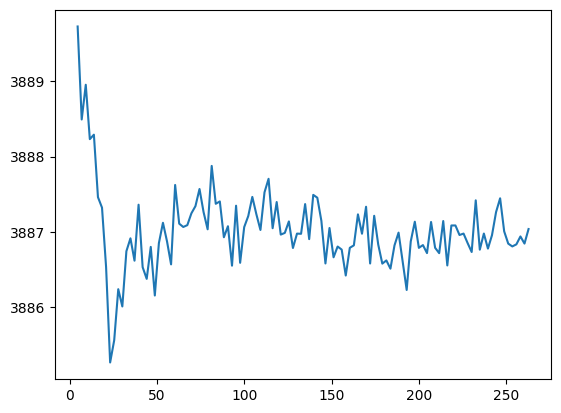

In [19]:

with open('supplement_data/q1_uncompensated.pkl', 'rb') as f:
    ff_uncomp = DictUnpickler(f).load()

data_uncomp = ff_uncomp.__dict__   # convert to dict

# delay_pts_uncomp, cfreqs_uncomp = ff_uncomp.delay_pts * 4.65, ff_uncomp.center_freqs
delay_pts_uncomp, cfreqs_uncomp = ff_uncomp.times_vec, ff_uncomp.center_freqs
print(delay_pts_uncomp)
cutoff_idx_uncomp        = ff_uncomp.cutoff_idx
specamp_uncomp           = ff_uncomp.specamp
spec_fpts_uncomp         = ff_uncomp.spec_fpts

print(len(delay_pts_uncomp), len(cfreqs_uncomp), cutoff_idx_uncomp)

plt.plot(delay_pts_uncomp, cfreqs_uncomp[cutoff_idx_uncomp:])
plt.show()
# plt.pcolormesh(spec_fpts_uncomp, delay_pts_uncomp, specamp_uncomp)
# plt.show()





with open('supplement_data/q1_compensated.pkl', 'rb') as f:
    ff_comp = DictUnpickler(f).load()

data_comp = ff_comp.__dict__   # convert to dict

delay_pts_comp, cfreqs_comp = ff_comp.times_vec, ff_comp.center_freqs
cutoff_idx_comp        = ff_comp.cutoff_idx
specamp_comp           = ff_comp.specamp
spec_fpts_comp         = ff_comp.spec_fpts

plt.plot(delay_pts_comp, cfreqs_comp[cutoff_idx_comp:])
plt.show()
# plt.pcolormesh(spec_fpts_comp, delay_pts_comp, specamp_comp)
# plt.show()

In [24]:
ideal_value = np.mean(cfreqs_comp[-10:])
print(ideal_value)

start_value = 4409
reflect_frequency = 3950

reflect = False

timestep = delay_pts_comp[1] - delay_pts_comp[0]
ideal_delay_pts = [delay_pts_comp[0] - timestep] + list(delay_pts_comp)


cfreqs_comp_reflect = cfreqs_comp.copy()
cfreqs_uncomp_reflect = cfreqs_uncomp.copy()
if reflect:
    cfreqs_comp_reflect = 2*reflect_frequency - cfreqs_comp_reflect
    cfreqs_uncomp_reflect = 2*reflect_frequency - cfreqs_uncomp_reflect


ideal_array = [start_value] + [ideal_value] * len(cfreqs_comp[cutoff_idx_comp:])

3886.9973895292073


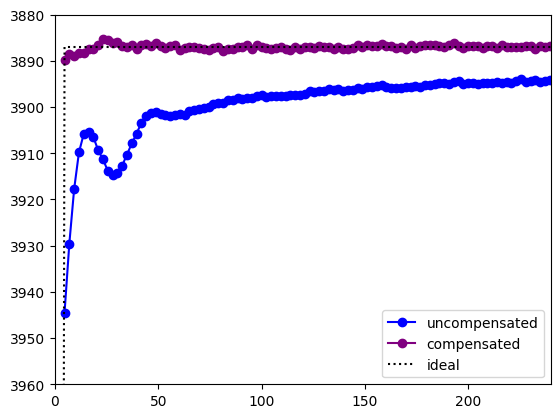

In [26]:
plt.plot(delay_pts_uncomp, cfreqs_uncomp_reflect[cutoff_idx_uncomp:], color='blue', marker='o', label='uncompensated')
plt.plot(delay_pts_comp, cfreqs_comp_reflect[cutoff_idx_comp:], color='purple', marker='o', label='compensated')

plt.plot(ideal_delay_pts, ideal_array, label='ideal', color='black', linestyle=':')


if reflect:
    plt.ylim(2*reflect_frequency - 3880,2*reflect_frequency - 3960)
else:
    plt.ylim(3880,3960)
    plt.ylim(3960,3880)

plt.xlim(0, 240)

plt.legend()

plt.show()

In [28]:
pulse_comp_filename = 'supplement_data/pulse_compensation_data.csv'

with open(pulse_comp_filename, 'w') as f:
    writer = csv.writer(f)
    writer.writerow(delay_pts_uncomp)
    writer.writerow(cfreqs_uncomp_reflect[cutoff_idx_uncomp:])
    writer.writerow(delay_pts_comp)
    writer.writerow(cfreqs_comp_reflect[cutoff_idx_comp:])
    writer.writerow(ideal_delay_pts)
    writer.writerow(ideal_array)


# 3. Coupler Fits

Text(0.5, 0, 'Bias voltage (V)')

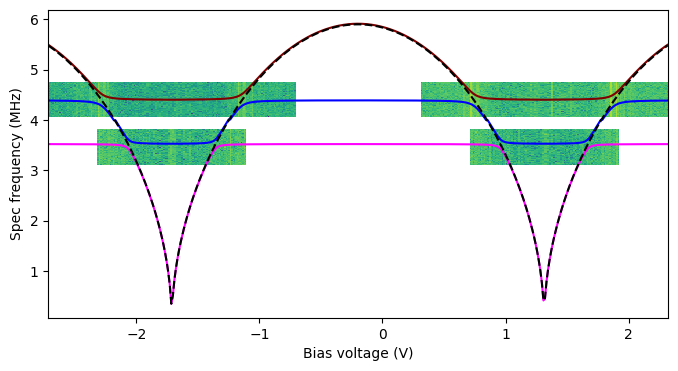

In [91]:
with open('supplement_data/coupler_fits.pkl', 'rb') as f:
    fitters = DictUnpickler(f).load()

fitter = fitters[0]
Vall             = fitter.Vall
middle_state_fit = fitter.middle_state_fit
higher_state_fit = fitter.higher_state_fit
lower_state_fit  = fitter.lower_state_fit
transmon_fit     = fitter.transmon_fit
meshes           = fitter.meshes

fig, ax = plt.subplots(figsize=(8,4))
plt.plot(Vall, higher_state_fit, color='maroon')
plt.plot(Vall, middle_state_fit, color='blue')
plt.plot(Vall, lower_state_fit,  color='magenta')
plt.plot(Vall, transmon_fit, '--', color='black')

for mesh_data in meshes:
    plt.pcolormesh(*mesh_data)

plt.ylabel("Spec frequency (MHz)")
plt.xlabel("Bias voltage (V)")

In [92]:
meshes[2][2].shape

(700, 98)

In [93]:
coupler_fit_data_filename = "supplement_data/coupler_fit_data.csv"
os.makedirs(os.path.dirname(coupler_fit_data_filename), exist_ok=True)

with open(coupler_fit_data_filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Vall", "lower_state_fit", "middle_state_fit", "higher_state_fit", "transmon_fit"])
    writer.writerows(zip(Vall, lower_state_fit, middle_state_fit, higher_state_fit, transmon_fit))

print(f"Saved: {coupler_fit_data_filename}")

Saved: supplement_data/coupler_fit_data.csv


In [94]:
meshes_h5_filename = "supplement_data/meshes_data.h5"
os.makedirs(os.path.dirname(meshes_h5_filename), exist_ok=True)

with h5py.File(meshes_h5_filename, "w") as f:
    meshes_group = f.create_group("meshes")
    meshes_group.attrs["count"] = len(meshes)

    for i, (x_points, y_points, z_points) in enumerate(meshes):
        x_points = np.asarray(x_points)
        y_points = np.asarray(y_points)
        z_points = np.asarray(z_points)

        print(f'mesh_{i}: x_points shape: {x_points.shape}, y_points shape: {y_points.shape}, z_points shape: {z_points.shape}')

        expected_shape = (len(y_points), len(x_points))
        if z_points.shape != expected_shape:
            raise ValueError(
                f"mesh_{i}: z_points shape {z_points.shape} does not match "
                f"cartesian-product shape {expected_shape} from (x_points, y_points)"
            )

        mesh_group = meshes_group.create_group(f"mesh_{i}")
        mesh_group.create_dataset("x_points", data=x_points)
        mesh_group.create_dataset("y_points", data=y_points)
        mesh_group.create_dataset("z_points", data=z_points, compression="gzip")

print(f"Saved: {meshes_h5_filename}")

mesh_0: x_points shape: (164,), y_points shape: (700,), z_points shape: (700, 164)
mesh_1: x_points shape: (164,), y_points shape: (700,), z_points shape: (700, 164)
mesh_2: x_points shape: (98,), y_points shape: (700,), z_points shape: (700, 98)
mesh_3: x_points shape: (98,), y_points shape: (700,), z_points shape: (700, 98)
Saved: supplement_data/meshes_data.h5
